# Import needed modules

In [1]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools
from pathlib import Path
import multiprocessing as mp
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

# import data handling tools
import cv2
import pydicom
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import categorical_crossentropy

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


# Create needed functions

## Function to create dataframe
We will use the _create_df()_ function to create train and validation dataframe depending on _define_trpaths()_ and _define_trdf()_ functions which are responsible for getting file paths.

In [2]:
def define_trpaths(train_data, train_csv):

    filepaths = []
    labels = []
    df = pd.read_csv(train_csv)
    files = os.listdir(train_data)

    for file, i in zip(sorted(files), df['cancer']):
        foldpath = os.path.join(train_data, file)
        files = os.listdir(foldpath)

        for f in files:
            fpath = os.path.join(foldpath, f)
            filepaths.append(fpath)
            if i == 0:
                labels.append('No Cancer')
            elif i == 1:
                labels.append('Cancer')
                
    return filepaths, labels

def define_trdf(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)

def create_df(train_data, train_csv):
    # train dataframe
    files, classes = define_trpaths(train_data, train_csv)
    df = define_trdf(files, classes)
    strat = df['labels']
    train_df, valid_df = train_test_split(df, train_size= 0.7, shuffle= True, random_state= 123, stratify= strat)
    
    return train_df, valid_df

## Function to trim data samples
we will use a function *trim()* that takes in a dataframe df, and integer max_size and a string column and returns a dataframe where the number of samples for any class specified by column is limited to max samples.

In [3]:
def trim (df, max_size, min_size, column):
    df = df.copy()
    original_class_count = len(list(df[column].unique()))
    print ('Original Number of classes in dataframe: ', original_class_count)
    
    sample_list = [] 
    groups = df.groupby(column)
    
    for label in df[column].unique():        
        group = groups.get_group(label)
        sample_count = len(group)     
        if sample_count > max_size :
            strat = group[column]
            samples, _ = train_test_split(group, train_size= max_size, shuffle= True, 
                                          random_state= 123, stratify= strat)            
            sample_list.append(samples)
      
        elif sample_count >= min_size:
            sample_list.append(group)
    
    df = pd.concat(sample_list, axis= 0).reset_index(drop= True)
    final_class_count = len(list(df[column].unique())) 
    if final_class_count != original_class_count:
        print ('*** WARNING***  dataframe has a reduced number of classes' )
    balance = list(df[column].value_counts())
    print (balance)
    return df

## Function to generate images from dataframe
_create_gens()_ function is responsible for generating batches of tensor image data with real-time data augmentation.

In [4]:
def create_gens(train_df, valid_df, train_dir):
    img_size = (224, 224)
    channels = 3
    batch_size = 40
    img_shape = (img_size[0], img_size[1], channels)
    
    def scalar(img):
        return img
    tr_gen = ImageDataGenerator(preprocessing_function= scalar, horizontal_flip= True)
    val_gen = ImageDataGenerator(preprocessing_function= scalar)
    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', directory = train_dir, target_size= img_size, class_mode= 'categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)
    valid_gen = val_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', directory = train_dir, target_size= img_size, class_mode= 'categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)

    return train_gen, valid_gen

## Function to show images
*show_images()* function is responsible for showing images sample from a specific directory after image generator.

In [5]:
def show_images(gen):
    g_dict = gen.class_indices
    classes = list(g_dict.keys())
    images, labels = next(gen)
    plt.figure(figsize= (20, 20))
    length = len(labels)
    sample = min(length, 25)
    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255
        plt.imshow(image)
        index = np.argmax(labels[i])
        class_name = classes[index]
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

## Callback Class
* We will use a custom callback class MyCallback which is responsible for modifying hyperparameters in run-time.

* It will inherit its parameters and hyperparameters from keras.callbacks.Callback.

In [6]:
### Define a class for custom callback
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, base_model, patience, stop_patience, threshold, factor, batches, initial_epoch, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.model = model
        self.base_model = base_model
        self.patience = patience # specifies how many epochs without improvement before learning rate is adjusted
        self.stop_patience = stop_patience # specifies how many times to adjust lr without improvement to stop training
        self.threshold = threshold # specifies training accuracy threshold when lr will be adjusted based on validation loss
        self.factor = factor # factor by which to reduce the learning rate
        self.batches = batches # number of training batch to runn per epoch
        self.initial_epoch = initial_epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch # save this value to restore if restarting training
        # callback variables
        self.count = 0 # how many times lr has been reduced without improvement
        self.stop_count = 0
        self.best_epoch = 1   # epoch with the lowest loss
        self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr)) # get the initial learning rate and save it
        self.highest_tracc = 0.0 # set highest training accuracy to 0 initially
        self.lowest_vloss = np.inf # set lowest validation loss to infinity initially
        self.best_weights = self.model.get_weights() # set best weights to model's initial weights
        self.initial_weights = self.model.get_weights()   # save initial weights if they have to get restored

    # Define a function that will run when train begins
    def on_train_begin(self, logs= None):
        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()

    def on_train_end(self, logs= None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print(msg)
        self.model.set_weights(self.best_weights) # set the weights of the model to the best weights

    def on_train_batch_end(self, batch, logs= None):
        acc = logs.get('accuracy') * 100 # get batch accuracy
        loss = logs.get('loss')
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
        print(msg, '\r', end= '') # prints over on the same line to show running batch count

    def on_epoch_begin(self, epoch, logs= None):
        self.ep_start = time.time()

    # Define method runs on the end of each epoch
    def on_epoch_end(self, epoch, logs= None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr)) # get the current learning rate
        current_lr = lr
        acc = logs.get('accuracy')  # get training accuracy
        v_acc = logs.get('val_accuracy')  # get validation accuracy
        loss = logs.get('loss')  # get training loss for this epoch
        v_loss = logs.get('val_loss')  # get the validation loss for this epoch

        if acc < self.threshold: # if training accuracy is below threshold adjust lr based on training accuracy
            monitor = 'accuracy'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc ) * 100 / self.highest_tracc # define improvement of model progres

            if acc > self.highest_tracc: # training accuracy improved in the epoch
                self.highest_tracc = acc # set new highest training accuracy
                self.best_weights = self.model.get_weights() # training accuracy improved so save the weights
                self.count = 0 # set count to 0 since training accuracy improved
                self.stop_count = 0 # set stop counter to 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1  # set the value of best epoch for this epoch

            else:
                # training accuracy did not improve check if this has happened for patience number of epochs
                # if so adjust learning rate
                if self.count >= self.patience - 1: # lr should be adjusted
                    lr = lr * self.factor # adjust the learning by factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer
                    self.count = 0 # reset the count to 0
                    self.stop_count = self.stop_count + 1 # count the number of consecutive lr adjustments
                    self.count = 0 # reset counter
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1 # increment patience counter

        else: # training accuracy is above threshold so adjust learning rate based on validation loss
            monitor = 'val_loss'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (self.lowest_vloss - v_loss ) * 100 / self.lowest_vloss
            if v_loss < self.lowest_vloss: # check if the validation loss improved
                self.lowest_vloss = v_loss # replace lowest validation loss with new validation loss
                self.best_weights = self.model.get_weights() # validation loss improved so save the weights
                self.count = 0 # reset count since validation loss improved
                self.stop_count = 0
                self.best_epoch = epoch + 1 # set the value of the best epoch to this epoch
            else: # validation loss did not improve
                if self.count >= self.patience - 1: # need to adjust lr
                    lr = lr * self.factor # adjust the learning rate
                    self.stop_count = self.stop_count + 1 # increment stop counter because lr was adjusted
                    self.count = 0 # reset counter
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer
                else:
                    self.count = self.count + 1 # increment the patience counter
                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1: # check if learning rate has been adjusted stop_count times with no improvement
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True # stop training

## Function to plot history of training
We will use plot_training() function for plotting trainning history items [accuracy and loss] in train data and validation data.

In [7]:
def plot_training(hist):
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]

    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout
    plt.show()


# Model Structure

### Show images sample

Original Number of classes in dataframe:  2
[10000, 797]
Original Number of classes in dataframe:  2
[5000, 342]
Found 10797 validated image filenames belonging to 2 classes.
Found 5342 validated image filenames belonging to 2 classes.


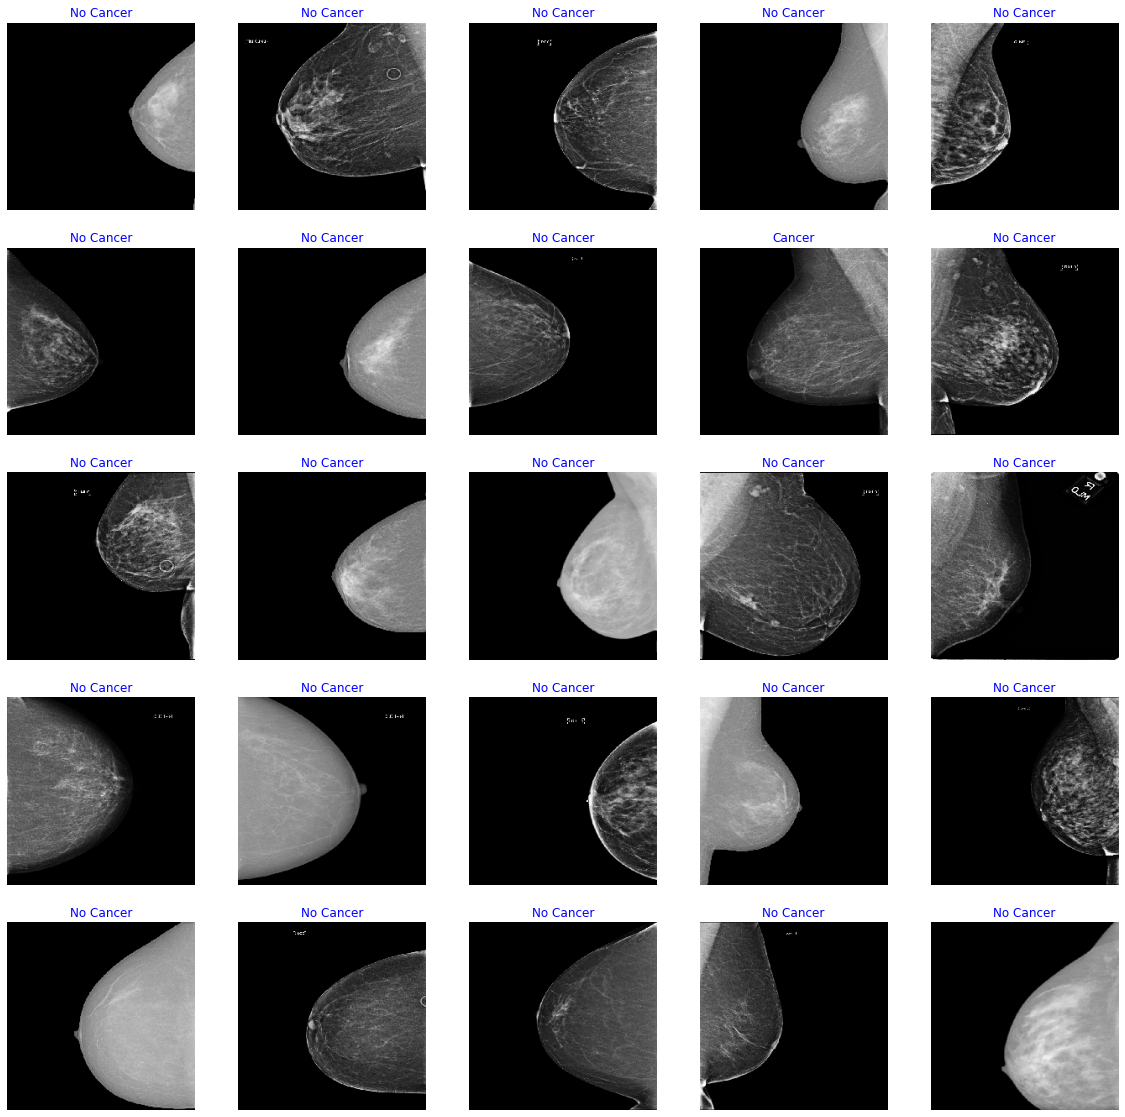

In [8]:
# Get Dataframes
train_data = '/kaggle/input/rsna-mammography-images-as-pngs/images_as_pngs_cv2_dicomsdl_512/train_images_processed_cv2_dicomsdl_512'
train_csv = '/kaggle/input/rsna-breast-cancer-detection/train.csv'

train_df, valid_df = create_df(train_data, train_csv)
train_df = trim(train_df, max_size = 10000, min_size = 0, column='labels')
valid_df = trim(valid_df, max_size = 5000, min_size = 0, column='labels')
# Get Generators
train_gen, valid_gen = create_gens(train_df, valid_df, train_data)

show_images(train_gen)

### Create Pre-trained model
We will use _EfficientNetB5

In [9]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model
base_model = tf.keras.applications.efficientnet.EfficientNetB3(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2(l= 0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()

2023-01-18 21:36:23.376424: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-18 21:36:23.470501: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-18 21:36:23.471263: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-18 21:36:23.472341: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

Exception: URL fetch failure on https://storage.googleapis.com/keras-applications/efficientnetb3_notop.h5: None -- [Errno -3] Temporary failure in name resolution

### Get custom callbacks parameters

In [ ]:
batch_size = 40
epochs = 20
patience = 1 		# number of epochs to wait to adjust lr if monitored value does not improve
stop_patience = 3 	# number of epochs to wait before stopping training if monitored value does not improve
threshold = 0.9 	# if train accuracy is < threshhold adjust monitor accuracy, else monitor validation loss
factor = 0.5 		# factor to reduce lr by
freeze = False 		# if true free weights of  the base model
ask_epoch = 5		# number of epochs to run before asking if you want to halt training
batches = int(np.ceil(len(train_gen.labels) / batch_size))

callbacks = [MyCallback(model= model, base_model= base_model, patience= patience,
            stop_patience= stop_patience, threshold= threshold, factor= factor,
            batches= batches, initial_epoch= 0, epochs= epochs, ask_epoch= ask_epoch )]

### Train model

In [ ]:
history = model.fit(x= train_gen, epochs= epochs, verbose= 0, callbacks= callbacks,
                    validation_data= valid_gen, validation_steps= None, shuffle= False,
                    initial_epoch= 0)

### Plot training history

In [ ]:
plot_training(history)

### Evaluate model

In [ ]:
train_score = model.evaluate(train_gen, verbose= 1)
valid_score = model.evaluate(valid_gen, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])

### Convert Dicoms to PNG

In [ ]:
def convert_images(filename, outdir):
    ds = pydicom.read_file(str(filename))
    img = ds.pixel_array
    img = cv2.resize(img, (128, 128))
    cv2.imwrite(outdir + filename.split('/')[-1][:-4] + '.png', img)

In [ ]:
test_path = '/kaggle/input/rsna-breast-cancer-detection/test_images'
test_out_path = '/kaggle/working/test_png/'

In [ ]:
if not os.path.exists(test_out_path):
    os.makedirs(test_out_path)

In [ ]:
import glob
test_dcm_list = glob.glob(os.path.join(test_path, '**/*.dcm'))

In [ ]:
res2 = Parallel(n_jobs=8, backend='threading')(delayed(
    convert_images)(i, test_out_path) for i in tqdm(test_dcm_list[:100], total=len(test_dcm_list)))

# Submission

In [ ]:
# Test Images

DATASET_PATH='/kaggle/input/rsna-breast-cancer-detection/'
test_df = pd.read_csv(os.path.join(DATASET_PATH, "test.csv"))
display(test_df.head())
print(f'cases: {len(test_df)}')

# Show sample submission example

df_sub = pd.read_csv(os.path.join(DATASET_PATH, "sample_submission.csv"))
display(df_sub.head())
print(f'cases: {len(df_sub)}')

In [ ]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.image.resize(img, [256, 256])
    img = tf.cast(img, dtype = tf.float32)
    img = img/255.0
    return img

In [ ]:
DF_PATH = '/kaggle/input/rsna-breast-cancer-detection'
df = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/test.csv")

test_path='/kaggle/working/test_png'

test_dir = f'{test_path}'
# /kaggle/working/test_png//10008/736471439.png
# /kaggle/working/test_png/736471439.png

test_df['img_path']= f'{test_dir}'\
                    + '/' + test_df.image_id.astype(str)\
                    + '.png'


test_df

In [ ]:
# Generate images
test_data = tf.keras.utils.image_dataset_from_directory("/kaggle/working/test_png",
                                                        labels=None, label_mode=None, color_mode='rgb',
                                                        image_size=(224,224), shuffle=False)

In [ ]:
# Get test prediction
preds = model.predict_generator(test_data)
# y_pred = np.argmax(preds, axis=1)
preds

In [ ]:
cancer = []
non_cancer = []
for p in preds:
    cancer.append(p[0])
    non_cancer.append(p[1])

print(cancer)
print(non_cancer)

In [ ]:
pred_df = pd.DataFrame({'prediction_id':test_df.prediction_id,
                        'cancer':cancer, 'non_cancer':non_cancer})

pred_df
# pred_df['cancer']=(pred_df.cancer > 0.5).astype(int)

### Save the model

In [ ]:
model_name = 'EffecientNetB3'
subject = 'rsna-breast-cancer-detection'
acc = valid_score[1] * 100
save_path = ''

save_id = str(f'{model_name}-{subject}-{"%.2f" %round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model.save(model_save_loc)
print(f'model was saved as {model_save_loc}')

In [ ]:
pred_df.to_csv('submission.csv', index=False)